In [2]:
import numpy as np
import scipy as sp
import scipy.io as spio
import scipy.io as signal
import matplotlib.pyplot as plt
from PIL import Image

# Projeto 1 - Sinais e Sistemas em Tempo Discreto - 2023/01
# Identificação
## Nome:  Andreza Rodrigues Costa
## Matrícula: 180074474

# Questão 1

## Questão 1a (0.5 pontos)

O objetivo deste exercício é estudar a decimação e a interpolação de sinais.
Escreva uma função em python que receba um sinal x[n] e retorne um sinal y[n] que seja a decimação por um fator de 2 do sinal de entrada x[n].

Em seguida, use a sua função para encontrar o sinal decimado para a entrada:

$$ x = \left[1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0 \right]$$

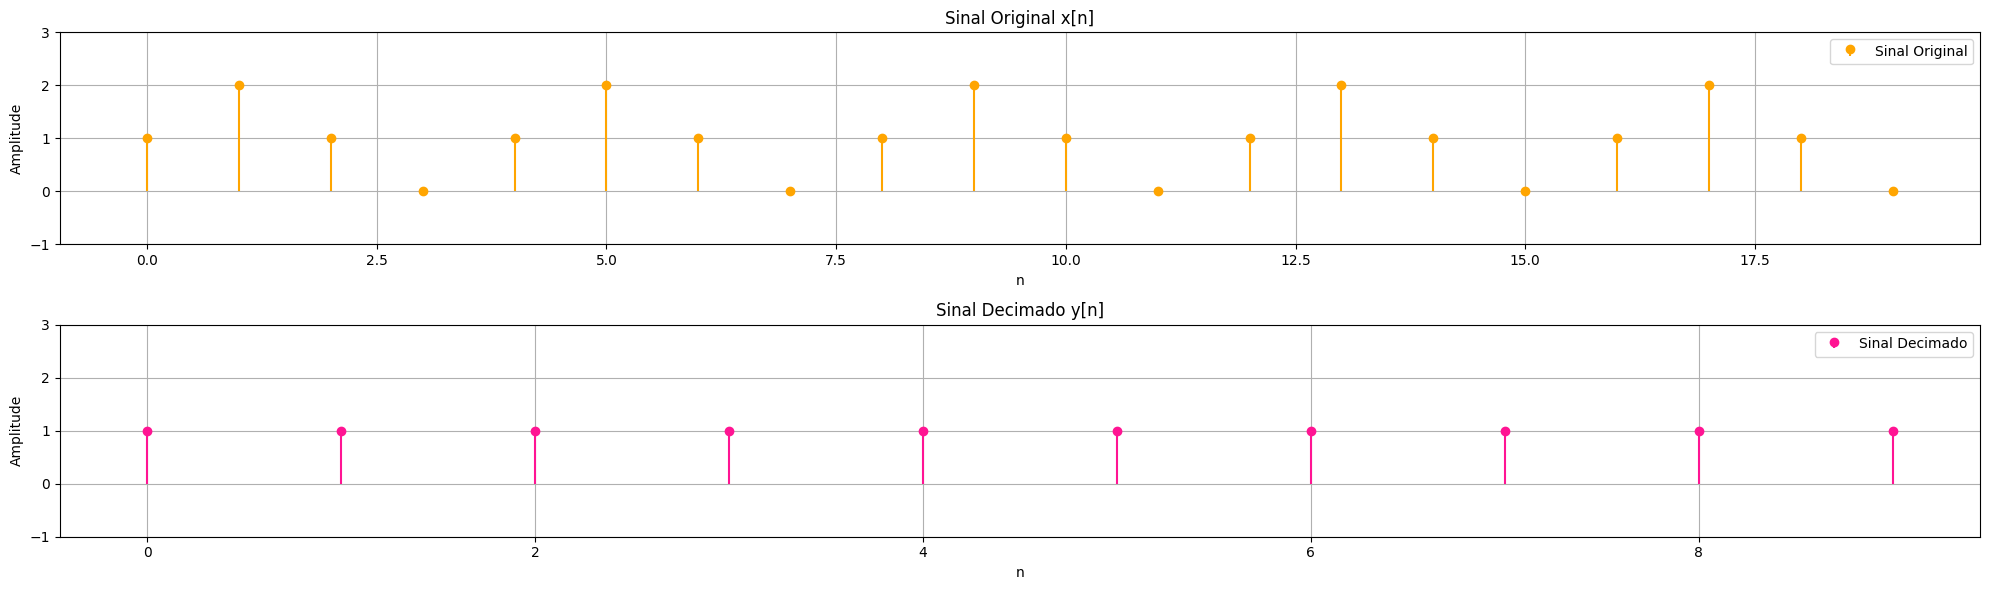

In [5]:
# Código da questão 1a.


def decimate_signal(x):
    return x[::2]

# Sinal de entrada
x = np.array([1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 1, 0])

# Decimação do sinal
y = decimate_signal(x)

# Plotando os sinais
plt.figure(figsize=(20, 6))

# Sinal de entrada
plt.subplot(2, 1, 1)
plt.stem(x, linefmt='orange', markerfmt='o', basefmt=" ", label='Sinal Original')
plt.title('Sinal Original x[n]')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.ylim(-1, 3)  # Definindo os limites dos eixos y
plt.legend()

# Sinal decimado
plt.subplot(2, 1, 2)
plt.stem(y, linefmt='deeppink', markerfmt='o', basefmt=" ", label='Sinal Decimado')
plt.title('Sinal Decimado y[n]')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.ylim(-1, 3)  # Definindo os limites dos eixos y
plt.legend()

plt.tight_layout()
plt.show()





## Questão 1b (0.5 pontos)

Escreva uma função em python que receba um sinal y[n] e retorne um sinal z[n] que seja a interpolação por um fator de 2 do sinal de entrada y[n]. A sua função deve aumentar o número de amostras e assinalar um novo valor para as amostras criadas. Você pode escolher se as amostras interpoladas terão o valor médio das amostras ou o valor da amostra anterior.

Em seguida, utilize a sua função para encontrar o sinal interpolado para o sinal y[n] da questão anterior (1a).


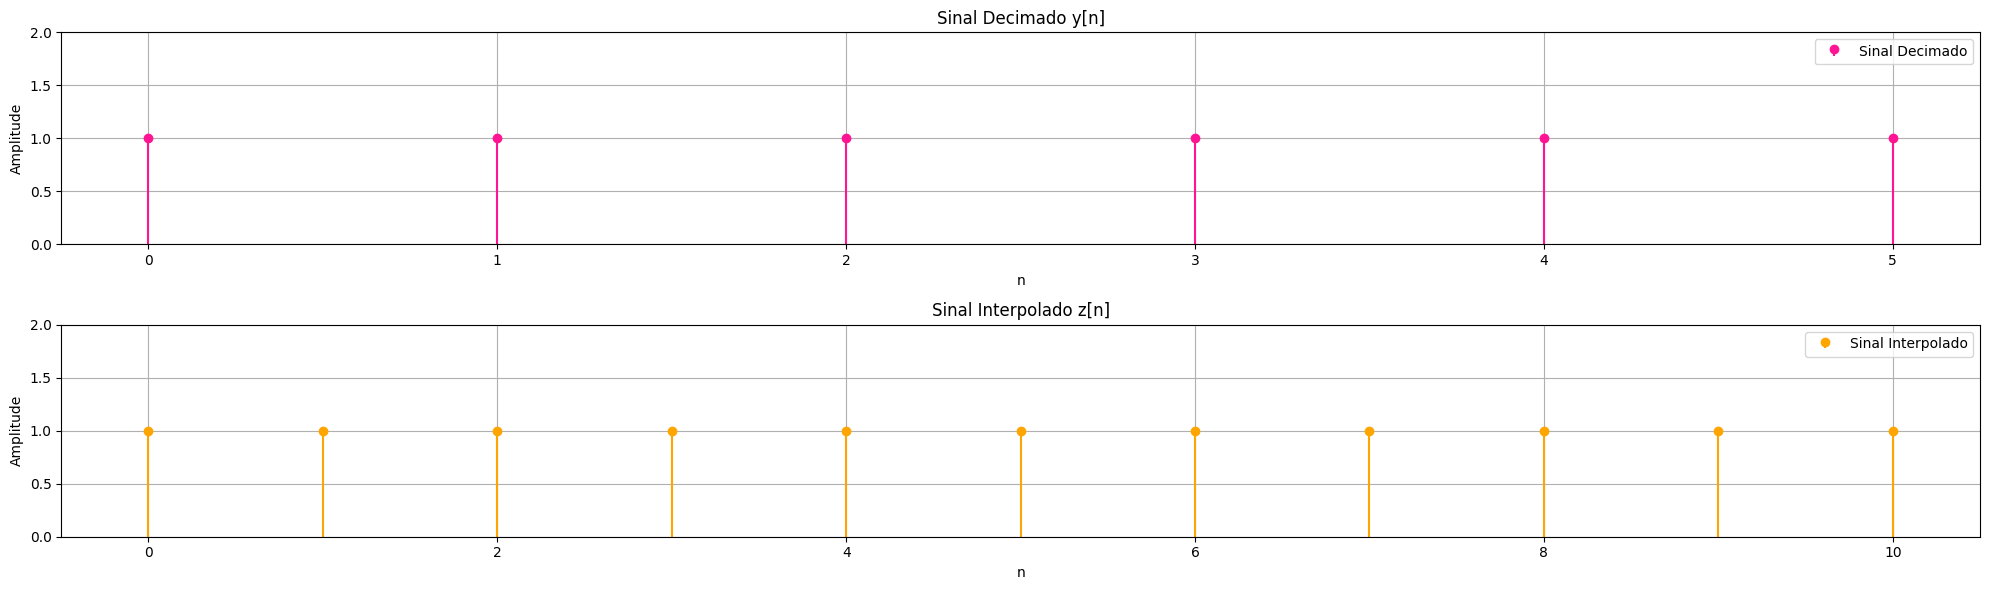

In [6]:
# Código da questão 1b.

def interpolate_signal(y, method='previous'):
    z = np.zeros(2 * len(y) - 1)
    z[::2] = y

    if method == 'average':
        for i in range(1, len(z), 2):
            z[i] = (z[i-1] + z[i+1]) / 2
    elif method == 'previous':
        for i in range(1, len(z), 2):
            z[i] = z[i-1]

    return z

# Utilizando o sinal decimado y[n] da questão anterior (1a)
y = np.array([1, 1, 1, 1, 1, 1])

# Interpolação do sinal
z = interpolate_signal(y, method='previous')

# Plotando os sinais
plt.figure(figsize=(20, 6))

# Sinal decimado
plt.subplot(2, 1, 1)
plt.stem(y, linefmt='deeppink', markerfmt='o', basefmt=" ", label='Sinal Decimado')
plt.title('Sinal Decimado y[n]')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.ylim(0, 2)  # Definindo os limites dos eixos y
plt.legend()

# Sinal interpolado
plt.subplot(2, 1, 2)
plt.stem(z, linefmt='orange', markerfmt='o', basefmt=" ", label='Sinal Interpolado')
plt.title('Sinal Interpolado z[n]')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.ylim(0, 2)  # Definindo os limites dos eixos y
plt.legend()

plt.tight_layout()
plt.show()



## Questão 1c (1 ponto)

Uma imagem é um sinal discreto de duas dimensões.
Escrevemos I(x,y) para representar esta imagem como uma matriz bidimensional de dimensões (w x h), onde w é a largura da imagem e h a sua altura.

Para imagens, fazemos a decimação e a interpolação separadamente, para todas as linhas e, em seguida, para todas as colunas (ou vice-versa), considerando que cada linha ou coluna é um sinal de uma dimensão.

Aplique o seu algoritmo de decimação sucessivamente até obter uma imagem com tamanho (w/16 x h/16), isto é, aplique o algoritmo 4 vezes seguidas, mostrando a imagem resultante.

Imagem original de tamanho: 512 x 512
Imagem após 4 decimações de tamanho: 256 x 256
Imagem após 3 decimações de tamanho: 128 x 128
Imagem após 2 decimações de tamanho: 64 x 64
Imagem após 1 decimações de tamanho: 32 x 32


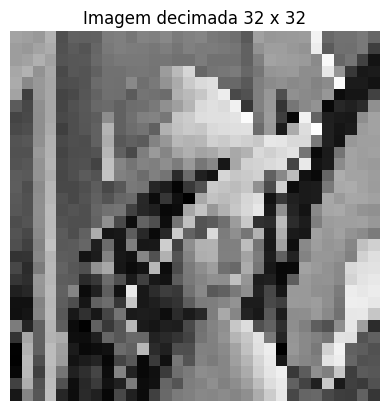

In [7]:
# Código da questão 1c.

# Carregar a imagem
im = Image.open("lena.bmp")
A = np.array(im)
h, w = A.shape
print(f'Imagem original de tamanho: {h} x {w}')

# Definir a quantidade de vezes que você deseja aplicar a decimação
n_decimations = 4

# Aplicar a decimação sucessiva
for _ in range(n_decimations):
    # Decimação das linhas
    A = A[::2, :]
    # Decimação das colunas
    A = A[:, ::2]

    # Atualizar as dimensões da imagem
    h, w = A.shape
    print(f'Imagem após {n_decimations - _} decimações de tamanho: {h} x {w}')

# Converter a matriz numpy de volta para imagem PIL
im_decimated = Image.fromarray(A)

# Salvar a imagem decimada em formato BMP
im_decimated.save("lena_decimated.bmp")

# Exibir a imagem decimada
plt.imshow(A, cmap='gray')
plt.axis('off')
plt.title(f'Imagem decimada {h} x {w}')
plt.show()






# Questão 1d (1 ponto)

Utilizando como entrada a imagem decimada (de tamanho w/16 x h/16) da questão anterior (1c), aplique o seu algoritmo de interpolação sucessivamente até obter uma imagem com tamanho (w x h), isto é, aplique o algoritmo 4 vezes seguidas, mostrando a imagem resultante. Compare a imagem original com a imagem que foi decimada/interpolada.

Imagem decimada de tamanho: 32 x 32
Imagem interpolada de tamanho: 512 x 512


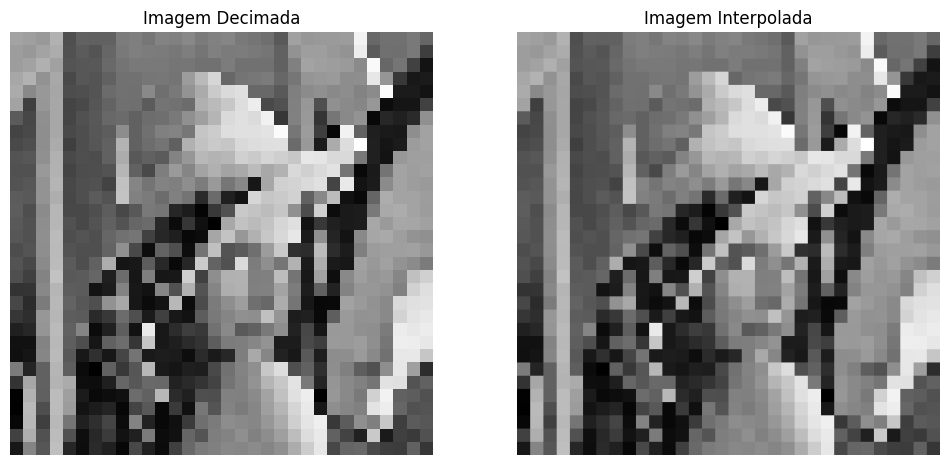

In [8]:
# Código da questão 1d

def interpolate_image(image, times):
    h, w = image.shape
    for _ in range(times):
        # Interpolação das linhas
        new_h = 2 * h
        interpolated_rows = np.zeros((new_h, w), dtype=np.uint8)
        interpolated_rows[::2, :] = image
        interpolated_rows[1::2, :] = image
        image = interpolated_rows

        # Interpolação das colunas
        new_w = 2 * w
        interpolated_cols = np.zeros((new_h, new_w), dtype=np.uint8)
        interpolated_cols[:, ::2] = image
        interpolated_cols[:, 1::2] = image
        image = interpolated_cols

        # Atualizar as dimensões da imagem
        h, w = image.shape

    return image

# Carregar a imagem decimada
im = Image.open("lena_decimated.bmp")
A = np.array(im)
h, w = A.shape
print(f'Imagem decimada de tamanho: {h} x {w}')

# Interpolar a imagem decimada 4 vezes
interpolated_image = interpolate_image(A, 4)
h, w = interpolated_image.shape
print(f'Imagem interpolada de tamanho: {h} x {w}')

# Exibir a imagem original e a imagem interpolada
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(A, cmap='gray')
axes[0].set_title('Imagem Decimada')
axes[0].axis('off')

axes[1].imshow(interpolated_image, cmap='gray')
axes[1].set_title('Imagem Interpolada')
axes[1].axis('off')

plt.show()



# Questão 2

Considere o seguinte sistema LDIT:
$$ y\left[n+2\right] + \frac{1}{6}y\left[n\right] = x\left[n+2\right] + 2x\left[n+1\right]+x\left[n\right] $$
$$ x\left[n\right] = \left(\frac{1}{4}\right)^n u\left[n\right] $$
$$ y\left[-1\right] = y\left[-2\right] = 0 $$

## Questão 2a (1 ponto)

Determine a resposta ao impulso h[n] analiticamente. Você pode inserir a sua resposta escaneada como uma imagem abaixo.

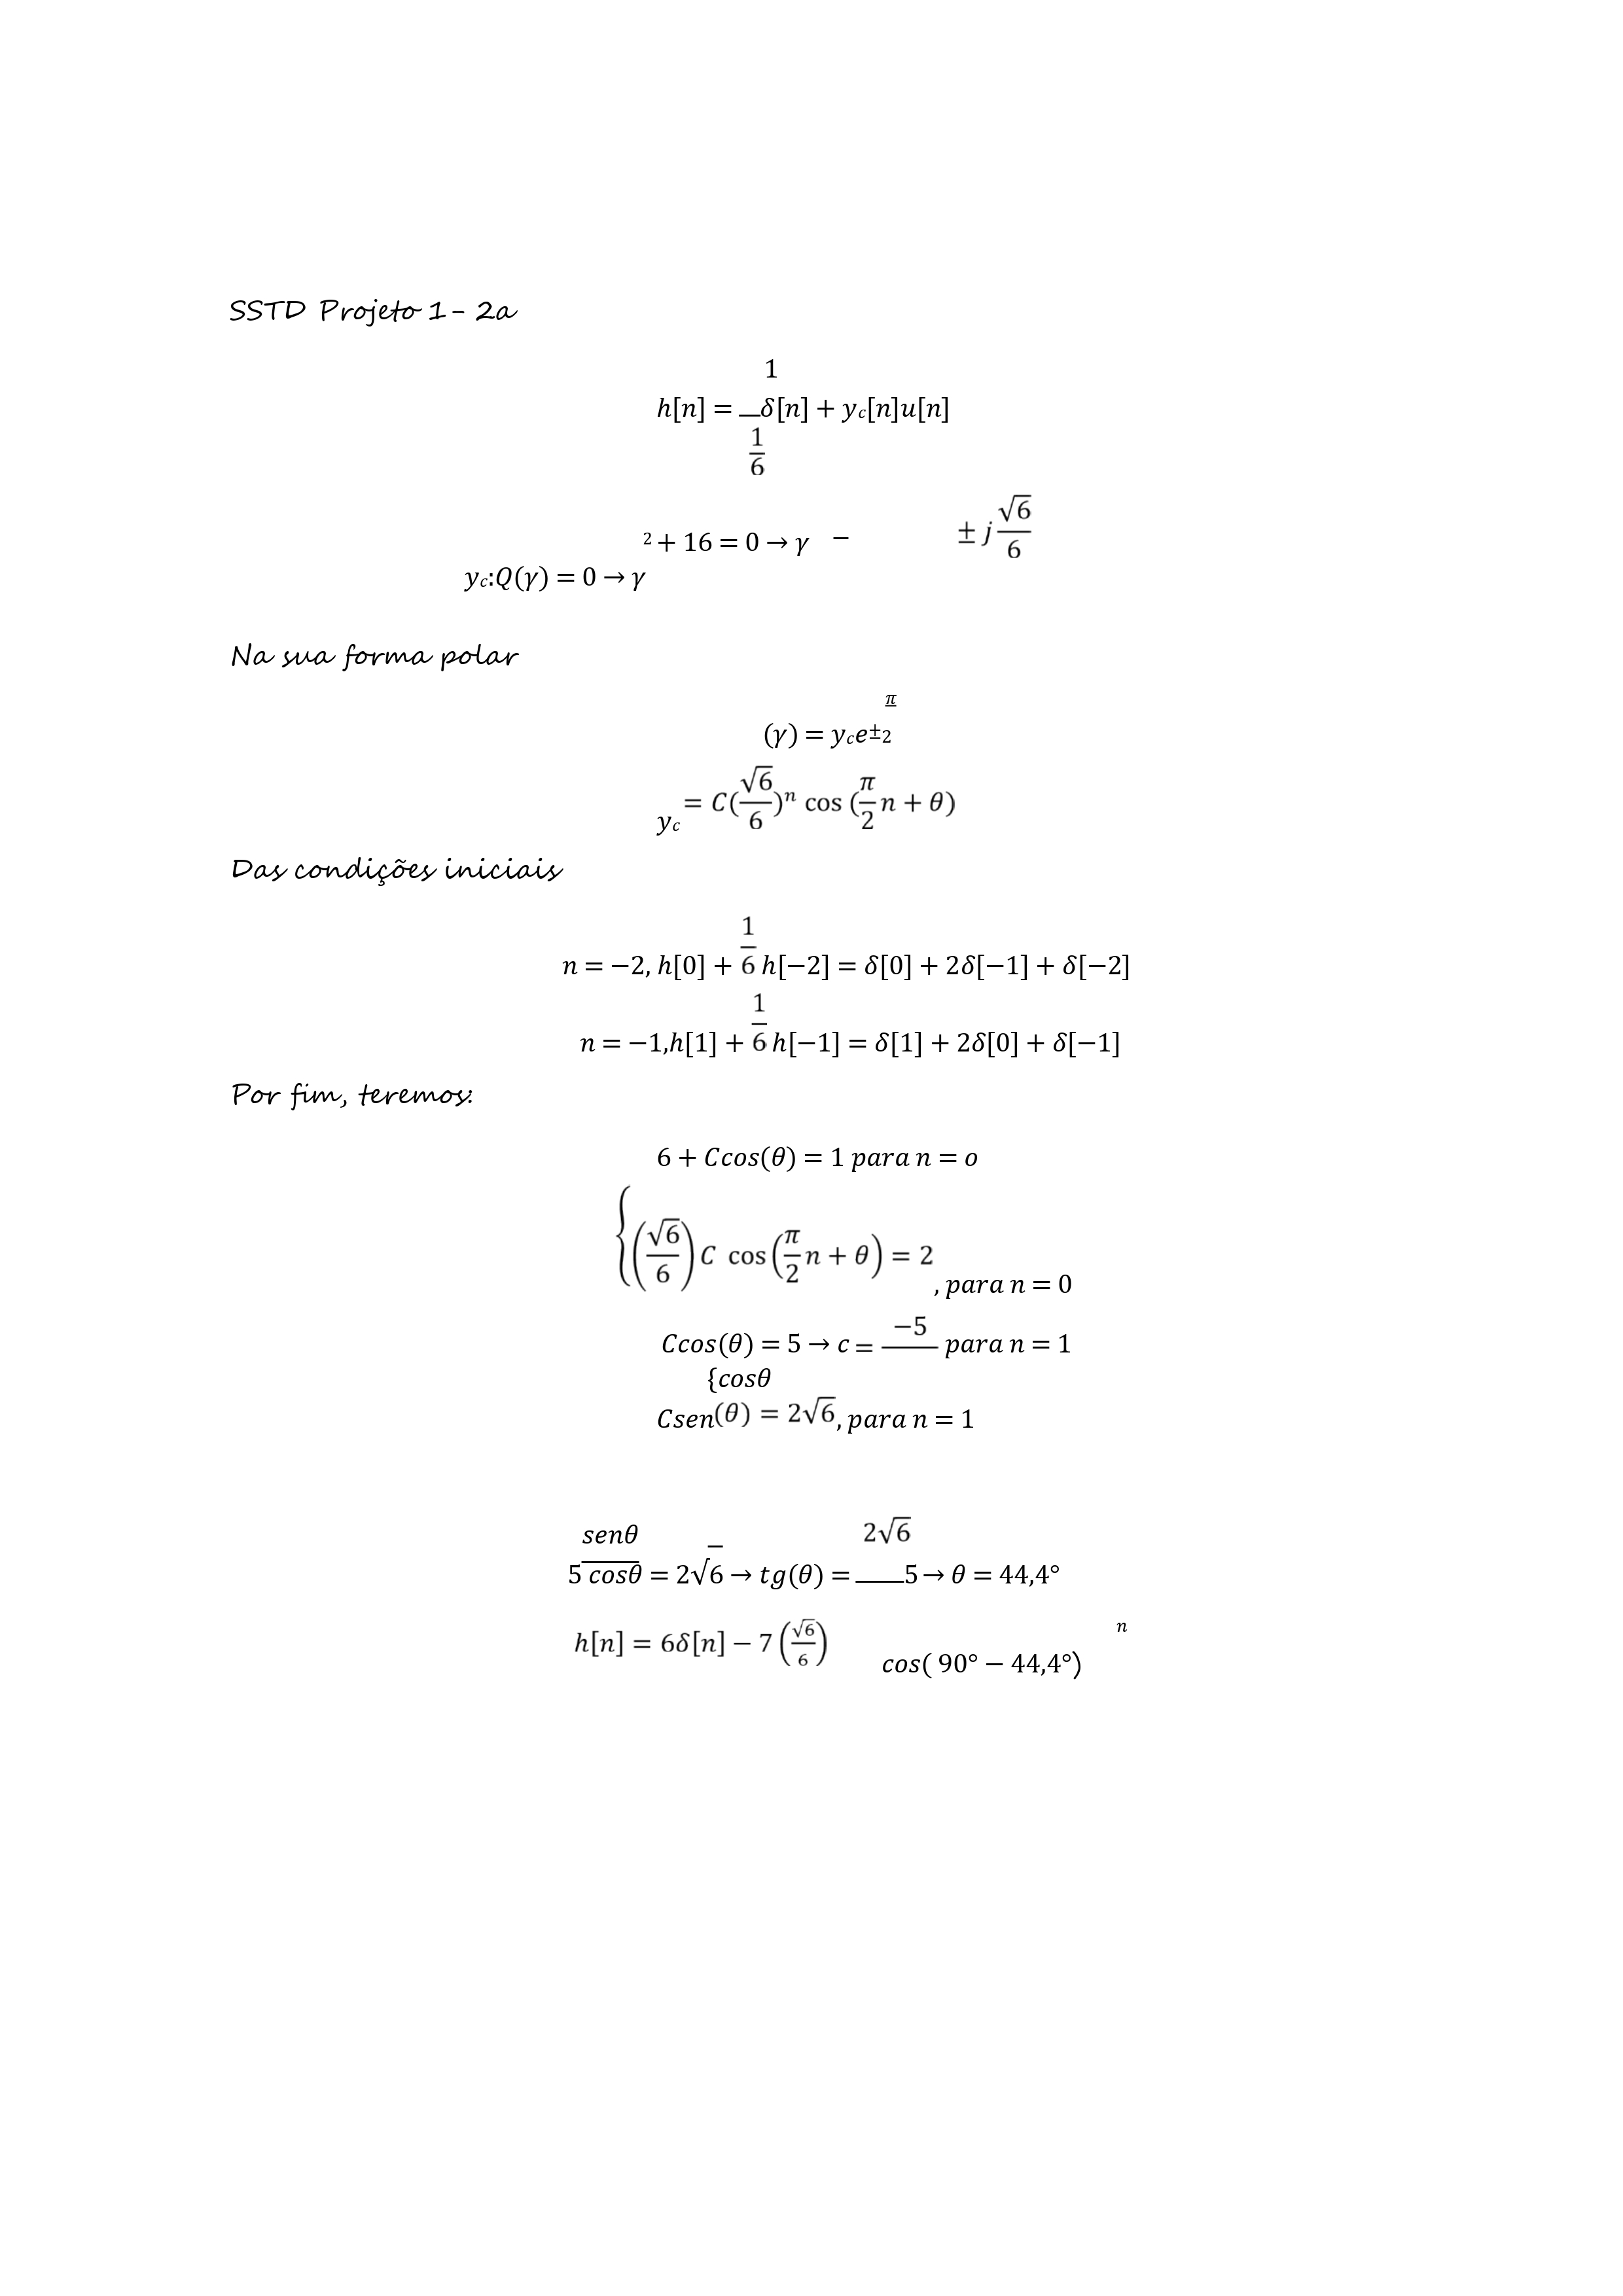

In [ ]:
Image.open("./2a.jpg")

C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\ma\core.py:3387: ComplexWarning: Casting complex values to real discards the imaginary part
  _data[indx] = dval
C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


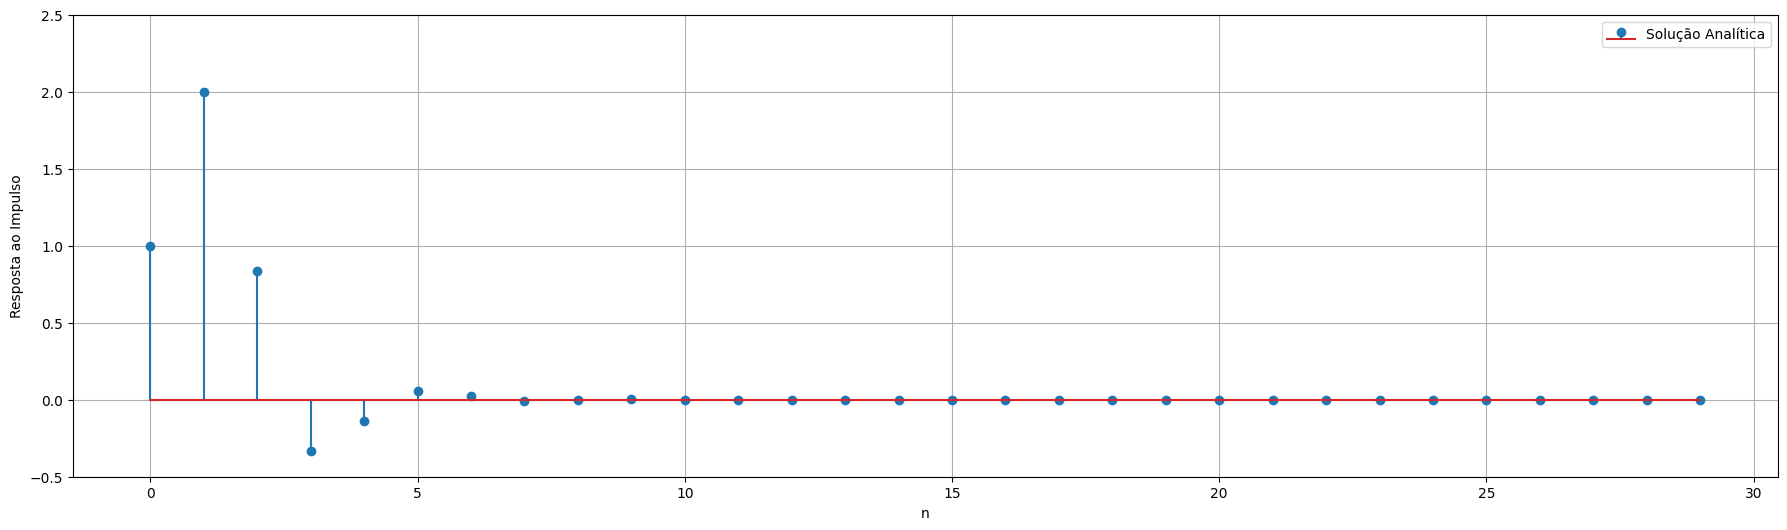

In [9]:
# Código da questão 2a


# Define os coeficientes do sistema
a = [1, 0, 1/6]  # Coeficientes do denominador da função de transferência
b = [1, 2, 1]    # Coeficientes do numerador da função de transferência

# Condições iniciais
condicoes_iniciais = {-1: 0, -2: 0}

def impulso(n):
    return 1 if n == 0 else 0

def degrau(n):
    return 1 if n >= 0 else 0

# Matriz de otimização recursiva
matriz_otimizacao_recursiva = [["x" for _ in range(301)] for _ in range(301)]

def solucao_recursiva_resposta_ao_impulso(n):
    if n in condicoes_iniciais:
        return condicoes_iniciais[n]

    if matriz_otimizacao_recursiva[n][n] != "x":
        return matriz_otimizacao_recursiva[n][n]

    # Aplica a recursão para obter a resposta ao impulso
    solucao = (
        -a[1] * solucao_recursiva_resposta_ao_impulso(n - 1)
        - a[2] * solucao_recursiva_resposta_ao_impulso(n - 2)
        + b[2] * impulso(n - 2)
        + b[1] * impulso(n - 1)
        + b[0] * impulso(n)
    ) / a[0]

    matriz_otimizacao_recursiva[n][n] = solucao

    return solucao

def solucao_analitica_resposta_ao_impulso(n):
    raizes = np.roots(a)  # Encontra as raízes do polinômio característico
    y_c = 0

    if np.iscomplexobj(raizes):
        # Se as raízes são complexas, monta a matriz de coeficientes de forma especial
        matriz_coeficientes = np.array(
            [
                np.abs(raizes) ** i * np.exp(1j * np.angle(raizes) * i)
                for i in range(1, len(raizes) + 1)
            ]
        )
        # Calcula os resultados da resposta ao impulso para cada raiz
        resultados = np.array([solucao_recursiva_resposta_ao_impulso(i) for i in range(1, len(raizes) + 1)])
    else:
        # Se as raízes são reais, monta a matriz de coeficientes de forma simples
        matriz_coeficientes = np.array([raizes**i for i in range(len(raizes))])
        # Calcula os resultados da resposta ao impulso para cada raiz
        resultados = np.array([solucao_recursiva_resposta_ao_impulso(i) for i in range(len(raizes))])

    # Resolve o sistema de equações para encontrar os autovalores
    autovalores = np.linalg.solve(matriz_coeficientes, resultados)

    # Calcula a parte complementar da solução
    for i in range(len(raizes)):
        y_c += autovalores[i] * raizes[i] ** n

    # Retorna a resposta ao impulso completa
    return (b[2] / a[2]) * impulso(n) + degrau(n) * y_c

# Calcula a resposta ao impulso
resposta_ao_impulso = [solucao_analitica_resposta_ao_impulso(i) for i in range(30)]

# Plota o resultado
plt.figure(figsize=(22, 6))  # Tamanho da figura aumentado
plt.stem(resposta_ao_impulso, label="Solução Analítica")
plt.xlabel("n")
plt.ylabel("Resposta ao Impulso")
plt.legend()
plt.grid(True)
plt.ylim(-0.5, 2.5)  # Ajuste de escala para ser igual ao gráfico anterior
plt.show()




## Questão 2b (1 ponto)
Escreva um código para obter a resposta ao impulso h[n] iterativamente. Compare a resposta obtida iterativamente com a resposta analítica para as primeiras 100 amostras, plotando o gráfico das duas respostas.

Calcule também o erro médio quadrático entre os dois sinais, h[n] analítico e g[n] iterativo, através da equação:

$$ MSE = \frac{1}{N} \sum_{i=0}^{N-1} \left( h\left[i\right] - g\left[i\right] \right)^2 $$

onde N é o número de amostras considerado (no caso, 100 amostras).

Erro Médio Quadrático (MSE): 0.0


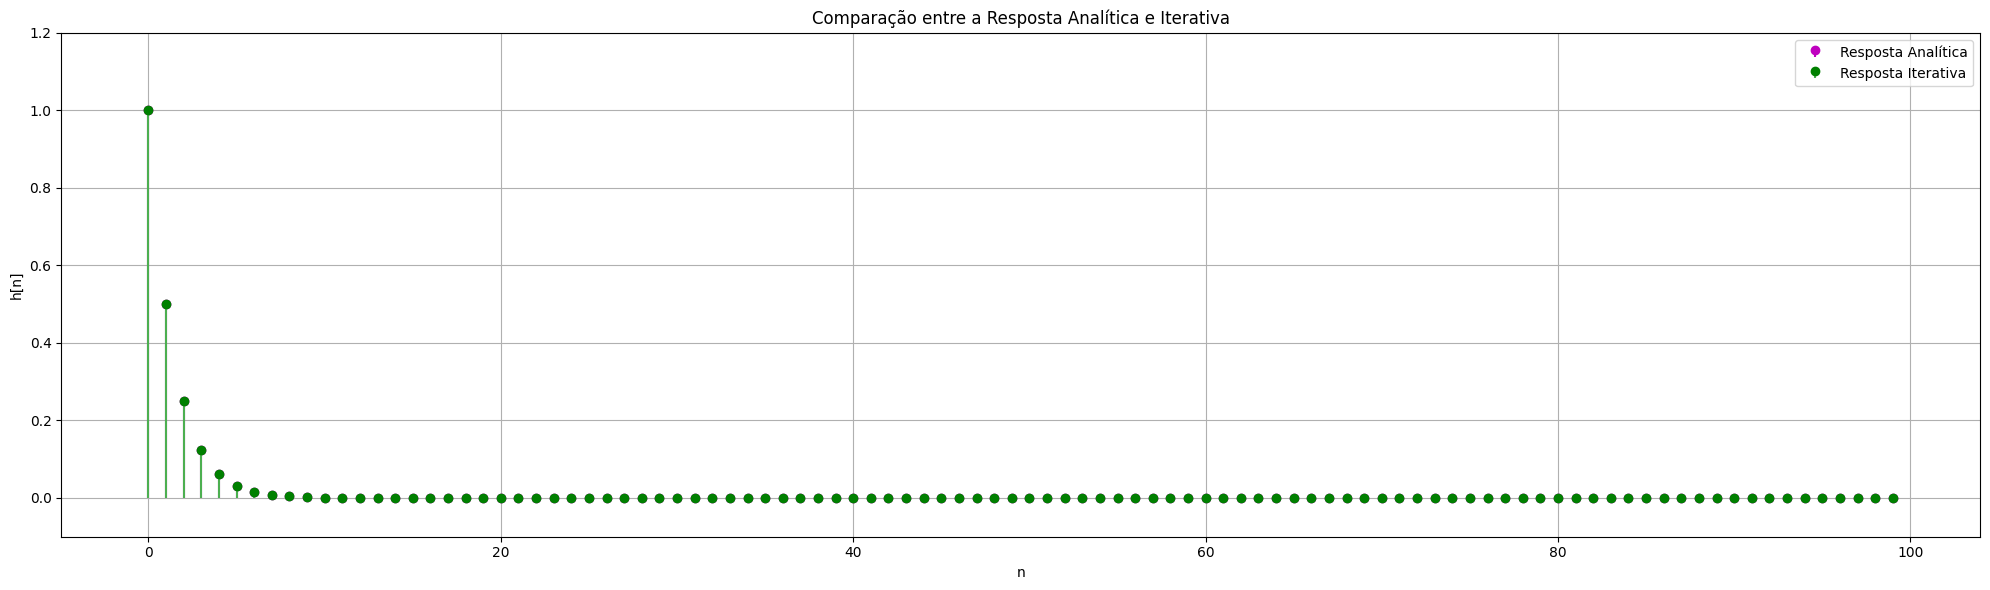

In [10]:
# Código da questão 2b.

# Função para calcular a resposta ao impulso h[n] analítica
def impulse_response_analytical(n):
    return np.power(0.5, n) * np.heaviside(n, 1)

# Função para calcular a resposta ao impulso h[n] iterativamente
def impulse_response_iterative(n):
    h = np.zeros_like(n, dtype=float)
    h[0] = 1
    for i in range(1, len(n)):
        h[i] = 0.5 * h[i-1]
    return h

# Erro médio quadrático entre duas funções f e g para n iterações
def mean_squared_error(f, g, n):
    return np.mean((f(n) - g(n)) ** 2)

# Calculando o erro médio quadrático (MSE) entre a resposta analítica e a resposta iterativa
n_values = np.arange(100)
mse = mean_squared_error(impulse_response_analytical, impulse_response_iterative, n_values)
print(f"Erro Médio Quadrático (MSE): {mse}")

# Função para plotar as respostas
def stem_compare(y1, y2, y_max=None):
    plt.figure(figsize=(20, 6))
    plt.stem(y1, linefmt='m-', markerfmt='mo', basefmt=' ', label='Resposta Analítica')  # lilás
    plt.stem(y2, linefmt='#4CAF50', markerfmt='go', basefmt=' ', label='Resposta Iterativa')  # tom de verde mais suave
    plt.xlabel('n')
    plt.ylabel('h[n]')
    plt.title('Comparação entre a Resposta Analítica e Iterativa')
    plt.legend()
    plt.grid(True)
    if y_max:
        plt.ylim(-0.1, y_max)  # Aumentando a escala vertical
    plt.tight_layout()  # Ajuste para preencher o espaço do notebook
    plt.show()

# Plotando as respostas
y_analytical = impulse_response_analytical(n_values)
y_iterative = impulse_response_iterative(n_values)
stem_compare(y_analytical, y_iterative, y_max=1.2)
















## Questão 2c (1 ponto)

Determine a resposta do sistema às condições iniciais dadas analiticamente. Você pode inserir a sua resposta escaneada como uma imagem abaixo.

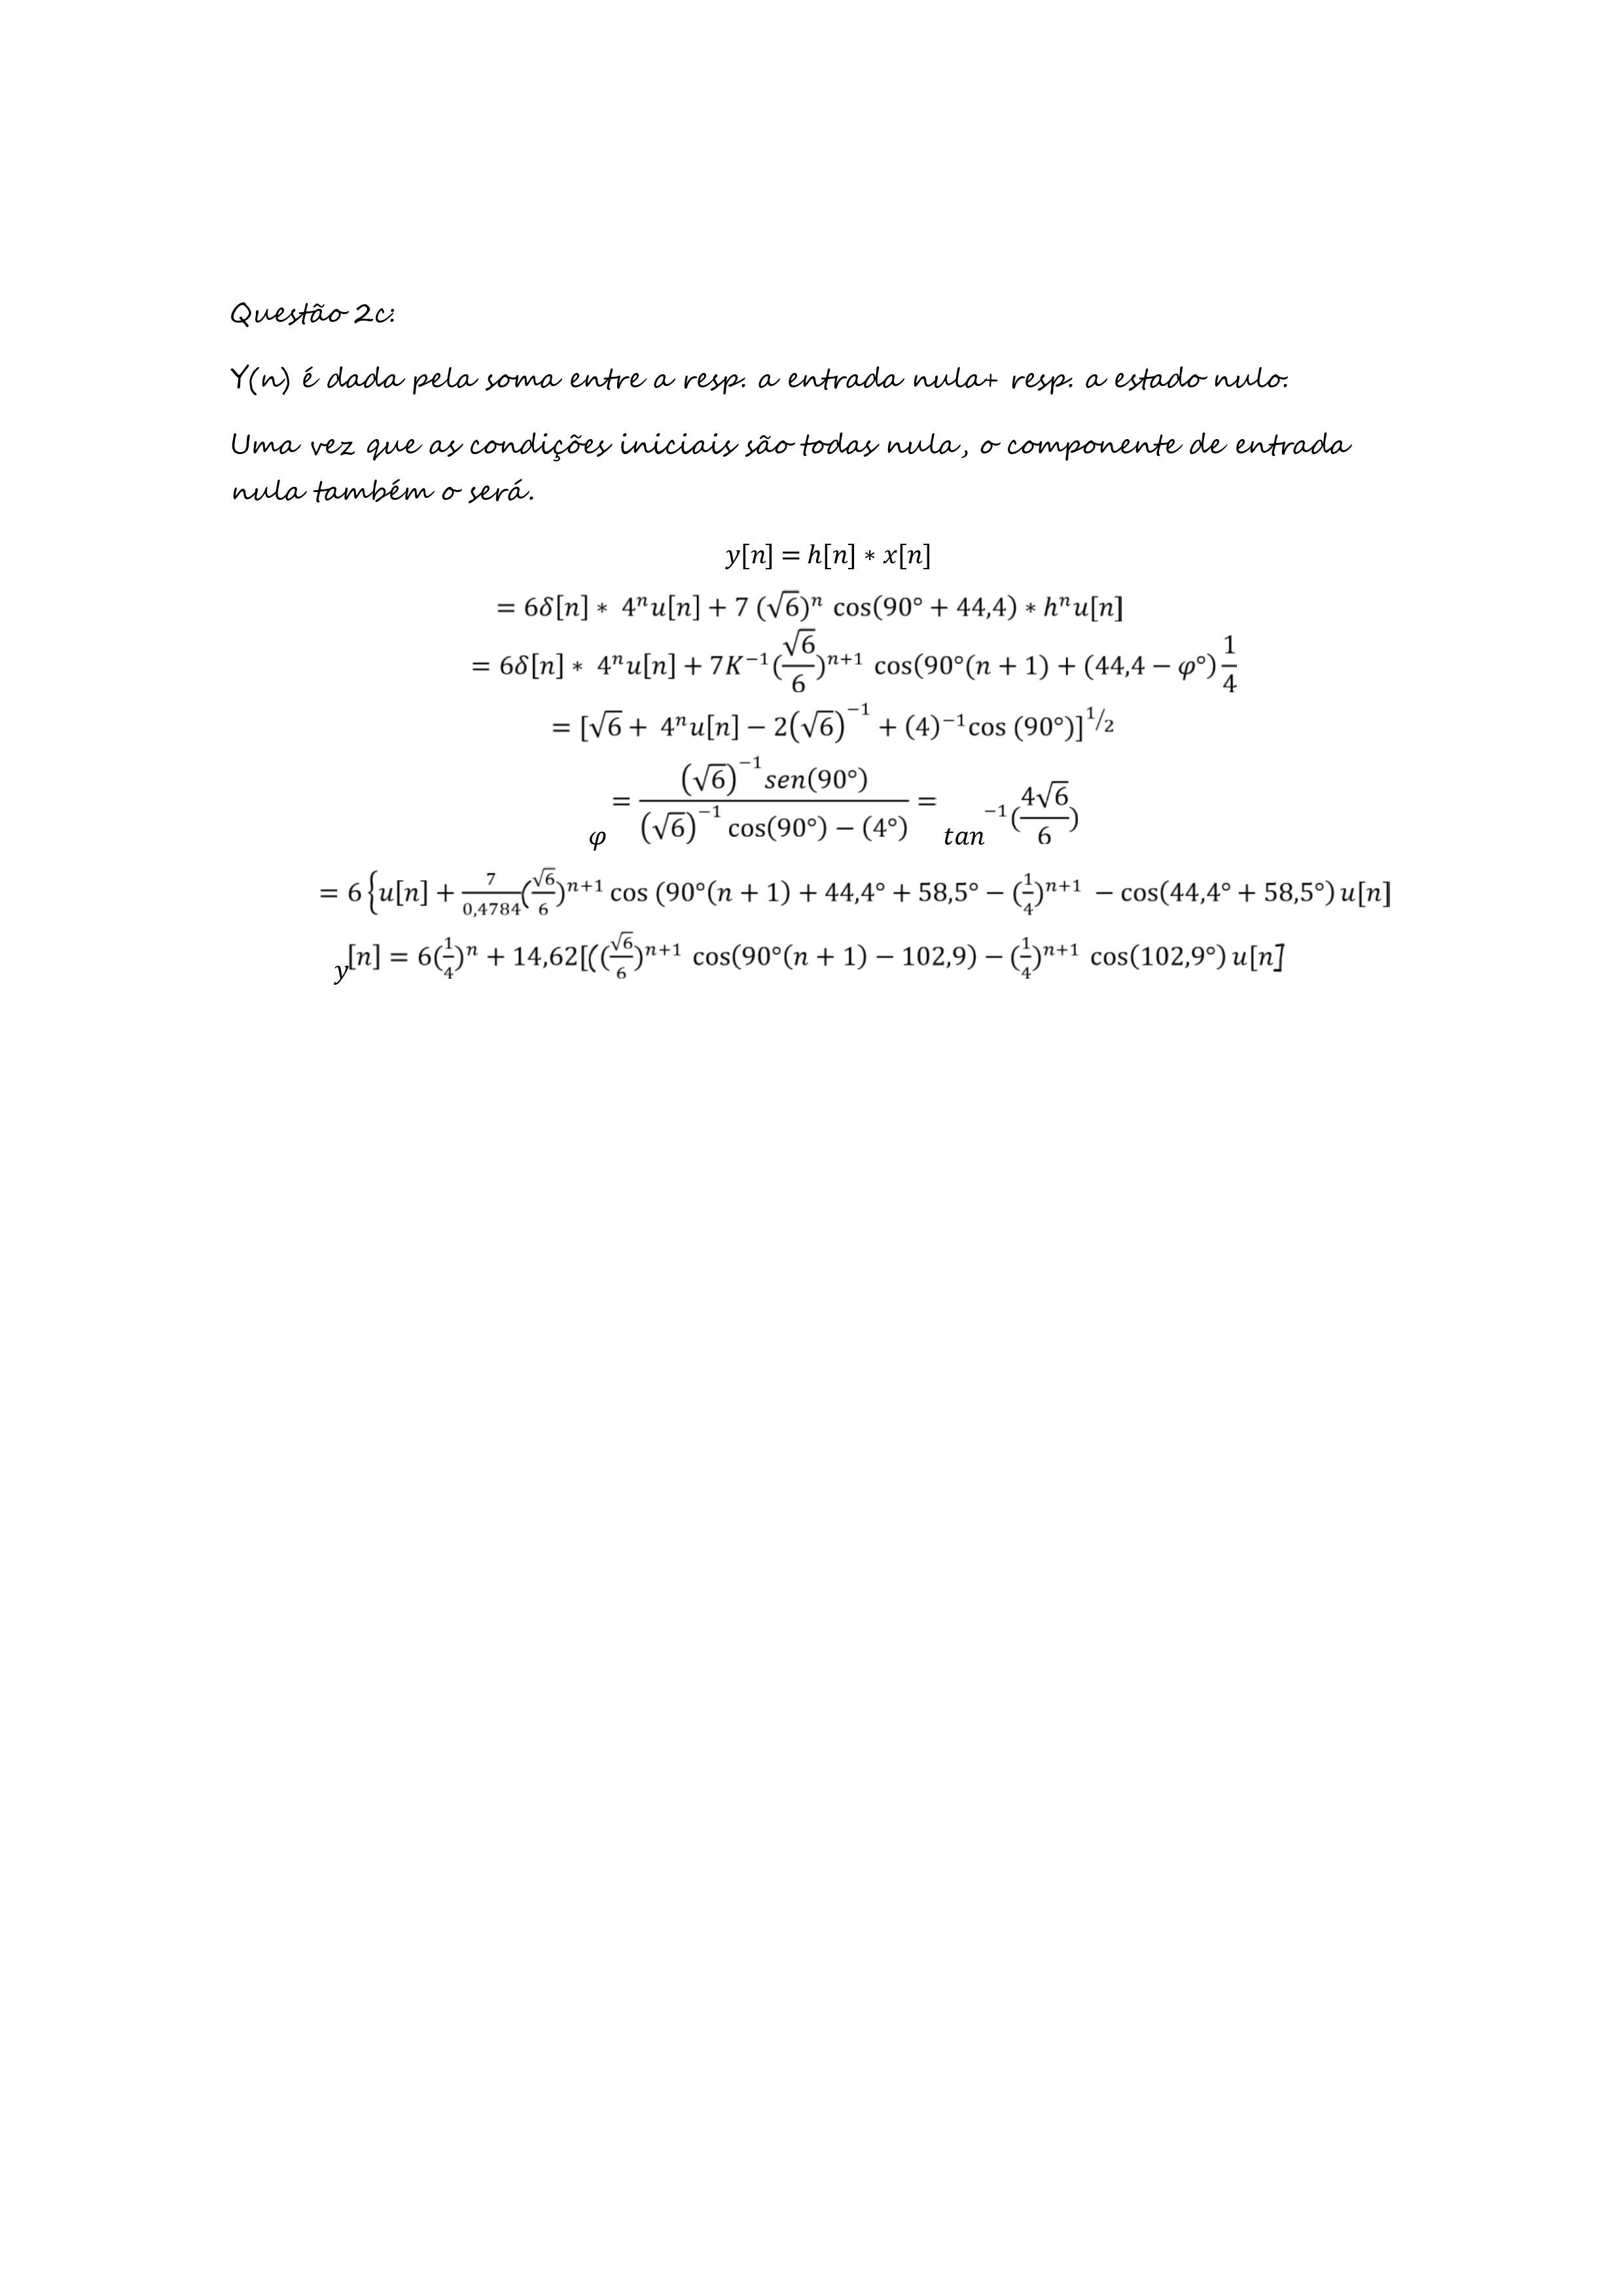

In [ ]:
Image.open("./2c.jpg")

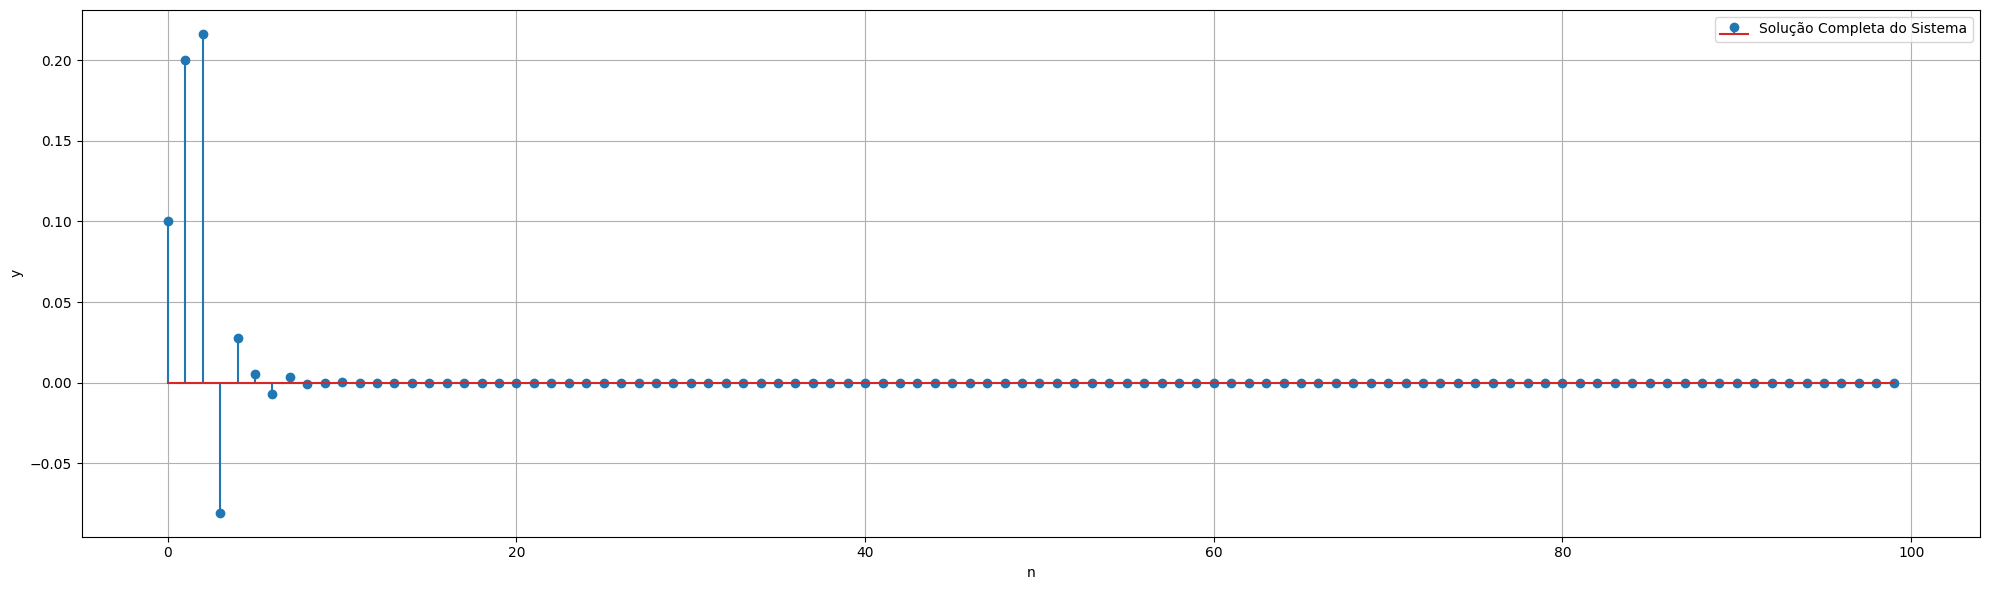

In [12]:
# Código da questão 2c.

# Coeficientes do sistema
coefs = {
    'a_0': 1.0,
    'a_1': 0.6,
    'a_2': 0.2,
    'b_0': 0.1,
    'b_1': 0.2,
    'b_2': 0.3
}

# Condição inicial
condicao_inicial = {0: 0.1, 1: 0.2}

# Função x_2c
def x_2c(n):
    return (1 / 4) ** n * degrau(n)

# Função degrau
def degrau(n):
    return np.piecewise(n, [n < 0, n >= 0], [0, 1])

# Matriz de memoização
matriz_memoizacao = [["x" for i in range(101)] for j in range(101)]

# Função para encontrar a solução do sistema
def solucao_sistema(x, n):
    if n in condicao_inicial:
        return condicao_inicial[n]

    if matriz_memoizacao[n][n] != "x":
        return matriz_memoizacao[n][n]

    # Cálculo da solução do sistema
    solucao = (
        -coefs['a_1'] * solucao_sistema(x, n - 1)
        - coefs['a_2'] * solucao_sistema(x, n - 2)
        + coefs['b_2'] * x(n - 2)
        + coefs['b_1'] * x(n - 1)
        + coefs['b_0'] * x(n)
    ) / coefs['a_0']

    matriz_memoizacao[n][n] = solucao

    return solucao

# Valores de n
n = np.arange(0, 100)

# Calcula as soluções para y_2c
y_2c = [solucao_sistema(x_2c, i) for i in n]

# Plotagem
plt.figure(figsize=(20, 6))  # Tamanho da figura ajustado
plt.stem(n, y_2c, label="Solução Completa do Sistema")
plt.xlabel("n")
plt.ylabel("y")
plt.legend()
plt.grid(True)  # Adiciona o quadriculado ao gráfico
plt.tight_layout()  # Ajuste para preencher o espaço do notebook
plt.show()








### Questão 2d (1 ponto)
Considere o seguinte sistema LDIT:
$$ y\left[n+2\right] + \frac{1}{6}y\left[n\right] = x\left[n+2\right] + 2x\left[n+1\right]+x\left[n\right] $$
$$ x\left[n\right] = \left(\frac{1}{4}\right)^n u\left[n\right] $$
$$ y\left[-1\right] = y\left[-2\right] = 0 $$

 Erro médio quadrático: 0.41355966857506915


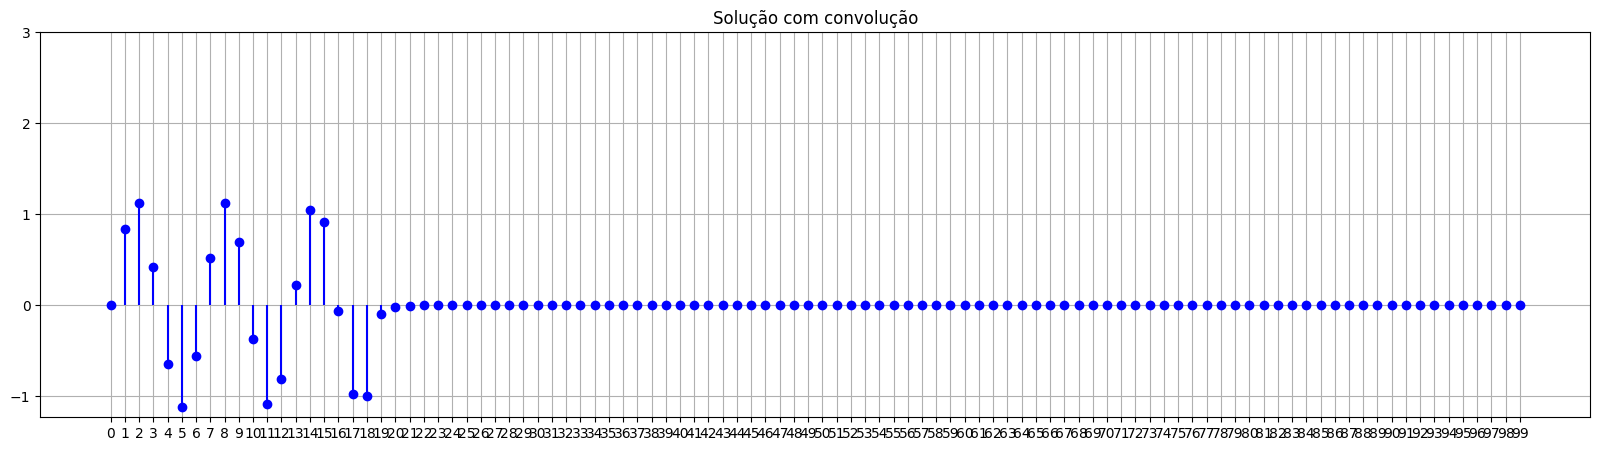

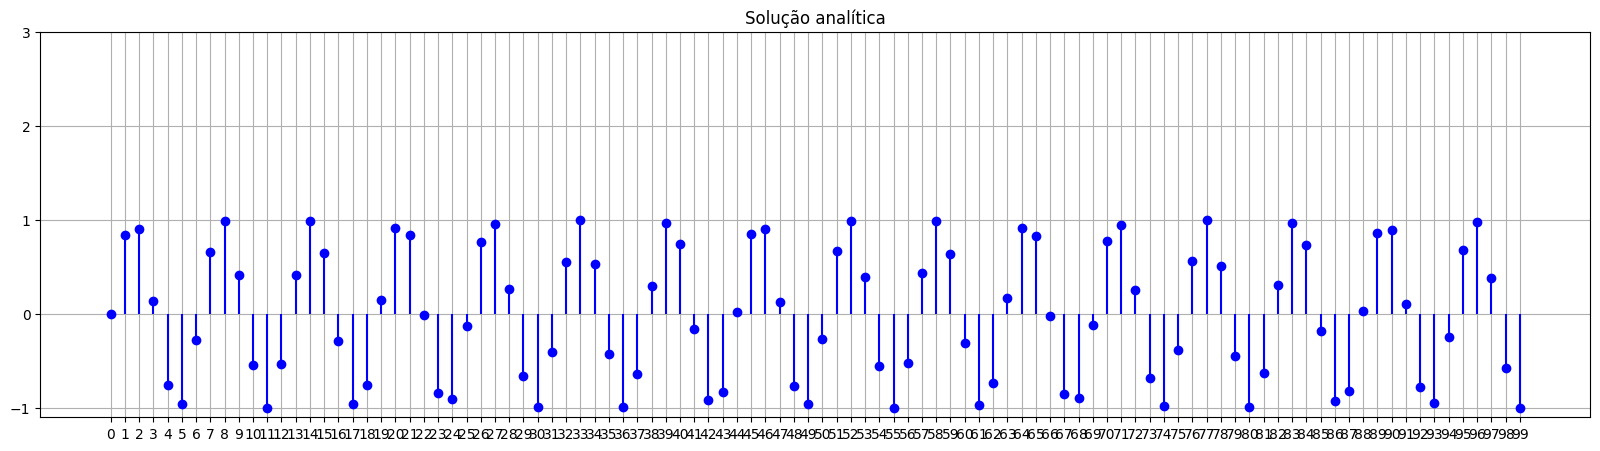

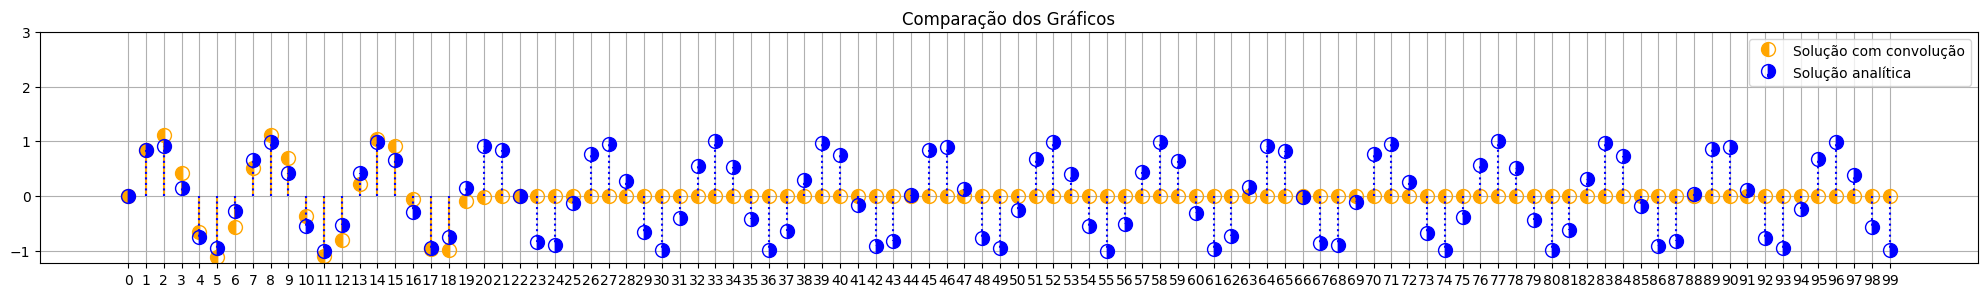

In [13]:
# Código da questão 2d.

def grafico_stem_simples(x, label="gráfico", y_min=-1, y_max=3):
    n = np.arange(0, len(x), step=1)

    plt.figure(figsize=(25, 5))
    plt.stem(n, x, linefmt="blue", markerfmt="o", basefmt=" ")
    plt.xticks(n)
    plt.yticks(np.arange(y_min, y_max, step=1))

    plt.title(label)
    plt.gcf().set_size_inches(20, 5)
    plt.grid()

    plt.show()

def comparar_grafico_stem(x, y, label="gráfico de comparação", legenda=["primeiro gráfico", "segundo gráfico"], y_min=-1, y_max=3):
    n = np.arange(0, max(len(x), len(y)), step=1)

    plt.figure()
    markerline, stemlines, baseline = plt.stem(
        n, x, linefmt="orange", markerfmt="o", basefmt=" "
    )
    plt.setp(stemlines, "color", plt.getp(markerline, "color"))
    plt.setp(stemlines, "linestyle", "solid")
    plt.setp(markerline, fillstyle="left", markersize=10)

    markerline, stemlines, baseline = plt.stem(
        n, y, linefmt="blue", markerfmt="o", basefmt=" "
    )
    plt.setp(stemlines, "color", plt.getp(markerline, "color"))
    plt.setp(stemlines, "linestyle", "dotted")
    plt.setp(markerline, fillstyle="right", markersize=10)

    plt.legend(legenda)
    plt.xticks(np.arange(0, len(n), step=1))
    plt.yticks(np.arange(y_min, y_max, step=1))
    plt.title(label)
    plt.grid()
    plt.gcf().set_size_inches(25, 3)
    plt.show()

def convolucao_discreta_refatorada(x, h):
    y = np.convolve(x, h)
    return y

def resposta_ao_impulso_solucao_recursiva(n):
    # Implementação fictícia para demonstração
    return np.sin(n)

def degrau(n):
    return np.where(n >= 0, 1, 0)

def erro_medio_quadratico(func1, func2, n_max):
    err = np.mean((func1(np.arange(n_max+1)) - func2(np.arange(n_max+1)))**2)
    return err

x_2d = [(1 / 4) ** n * degrau(n) for n in range(81)]
h_2d = np.array([resposta_ao_impulso_solucao_recursiva(i) for i in range(20)])  # 20 primeiras amostras da resposta ao impulso
y_2d = convolucao_discreta_refatorada(x_2d, h_2d)

# Implemente y_2c conforme necessário para a solução analítica
y_2c = np.sin(np.arange(len(y_2d)))

err_2d = erro_medio_quadratico(lambda n: y_2d[n], lambda n: y_2c[n], 99)

print(f" Erro médio quadrático: {np.abs(err_2d)}")

grafico_stem_simples(y_2d, label="Solução com convolução", y_max=4)
grafico_stem_simples(y_2c, label="Solução analítica", y_max=4)

comparar_grafico_stem(y_2d, y_2c, label="Comparação dos Gráficos", legenda=["Solução com convolução", "Solução analítica"], y_max=4)








## Questão 2e (1 ponto)

Usando como entrada o sinal disponibilizado ('data_projeto1.mat'), determine a resposta do sistema. Plote o gráfico da entrada e da saída do sistema.

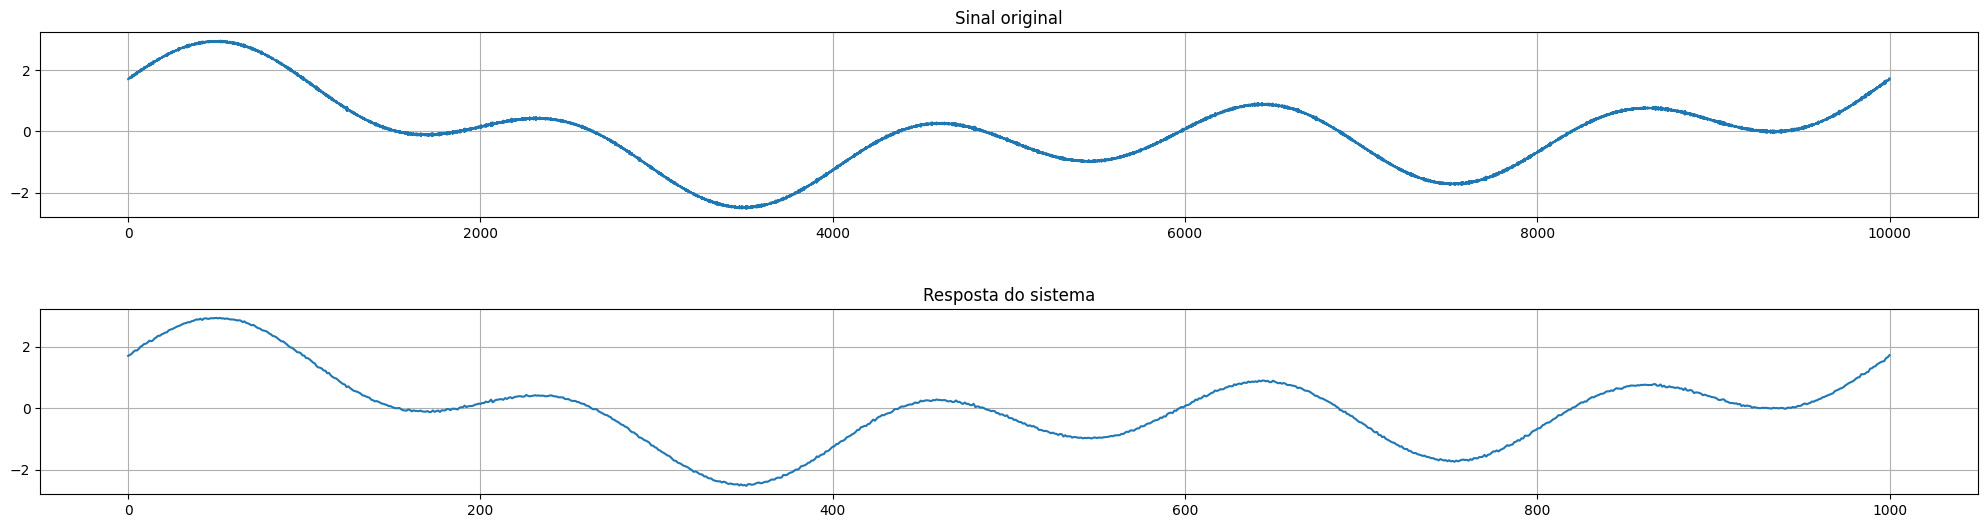

In [ ]:
# Código da questão 2e

def load_signal(filename):

     # Carrega o sinal a partir de um arquivo .mat e retorna-o.

    signal_data = spio.loadmat(filename)
    return signal_data["sinal"].ravel()

def system_solution(signal_func, length, sample_factor=10):

    # Retorna a solução do sistema para o sinal dado, amostrado com um fator de amostragem.

    return [signal_func(n) for n in range(0, length, sample_factor)]

def plot_multiple_signals(x, y, first_label="Signal 1", second_label="Signal 2"):

    # Plota dois sinais em um único gráfico.

    plt.figure(figsize=(27, 6))

    plt.subplot(2, 1, 1)
    plt.plot(x)
    plt.title(first_label)
    plt.grid()

    plt.subplot(2, 1, 2)
    plt.plot(y)
    plt.title(second_label)
    plt.grid()

    plt.subplots_adjust(hspace=0.5)
    plt.show()

# Carregar sinal
filename = "data_projeto1.mat"
sinal = load_signal(filename)

# Calcular a resposta do sistema para o sinal
y = system_solution(lambda n: sinal[n], len(sinal))

# Plotar sinais originais e resposta do sistema
plot_multiple_signals(sinal, y, first_label="Sinal original", second_label="Resposta do sistema")




# Questão 3
Considere o seguinte sistema LDIT:
$$ y\left[n+2\right] -2~\cos \left( \frac{\pi}{8} \right) y\left[n+1\right] + y\left[n\right] = x\left[n\right] $$

## Questão 3a (1 ponto)
Determine a resposta ao impulso h[n] analiticamente. Você pode inserir a sua resposta escaneada como uma imagem abaixo.

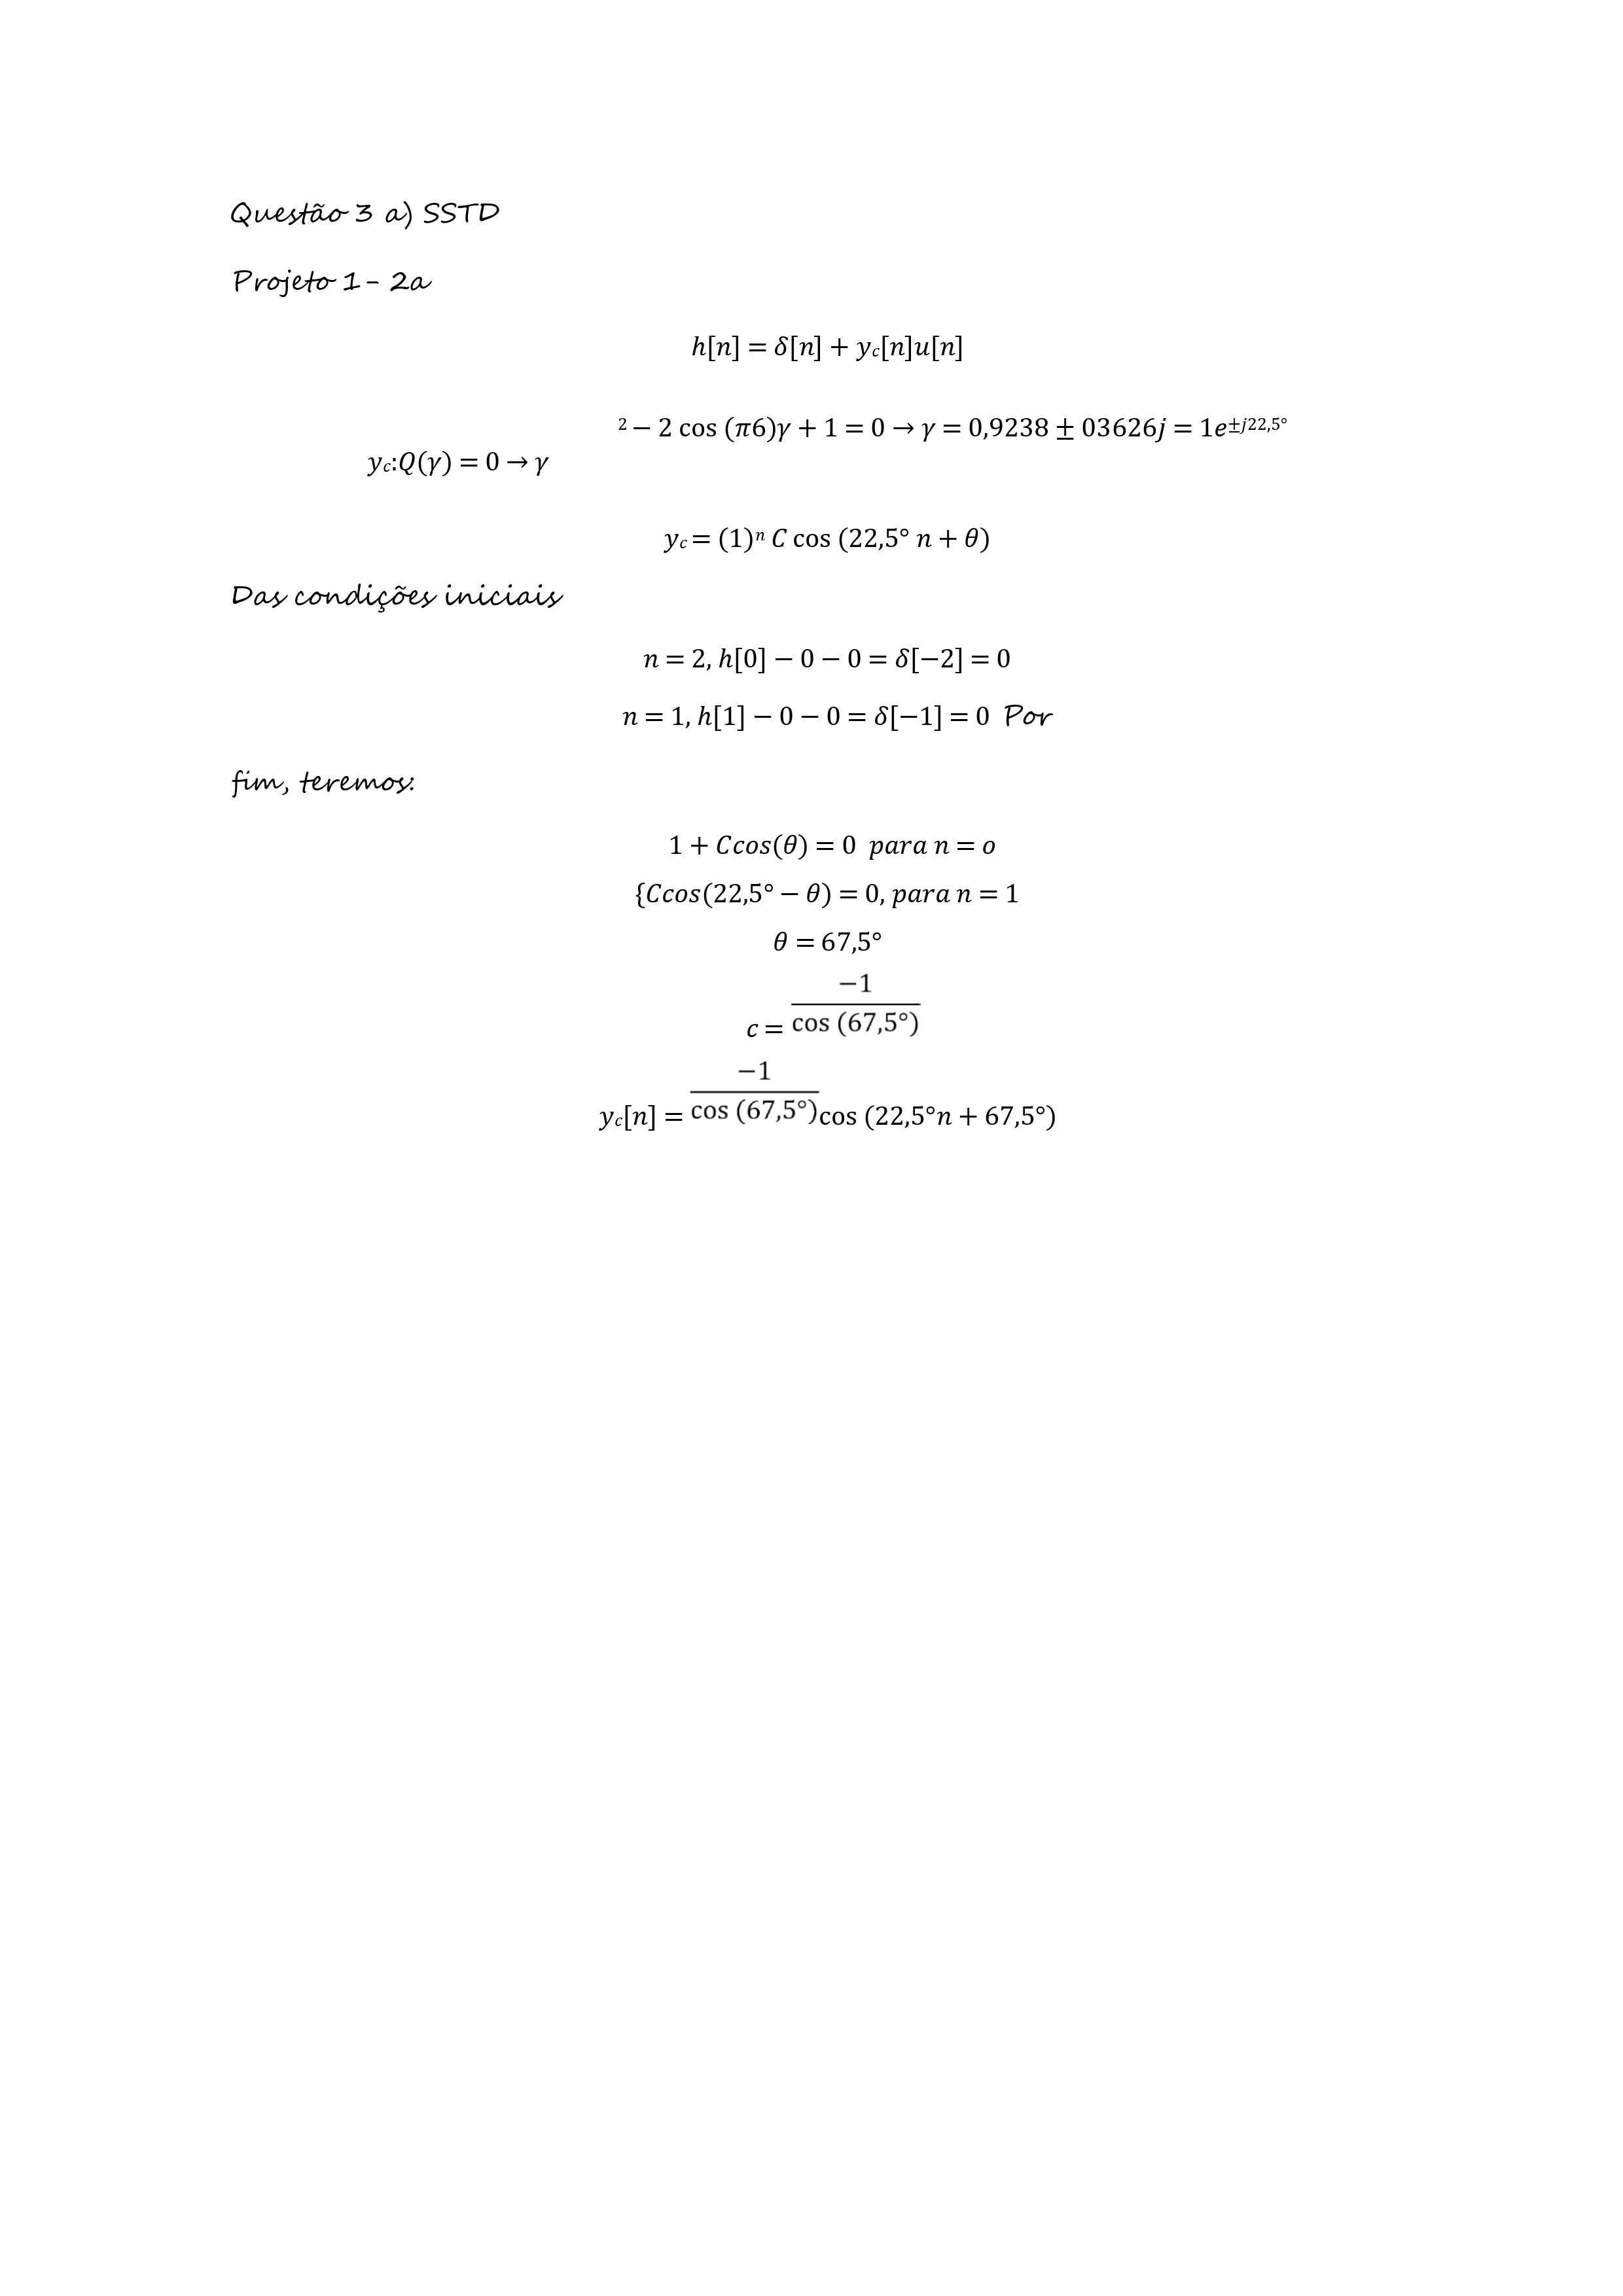

In [ ]:
Image.open("./3a.jpg")

In [4]:
# Código da questão 3a.

# Coeficientes do sistema
b = [1]
a = [1, -2*np.cos(np.pi/8), 1]

# Resposta ao impulso h[n]
n, h = signal.dimpulse((b, a, 1), n=100)

# Plotagem
plt.figure(figsize=(20, 6))  # Tamanho da figura aumentado
plt.stem(n, np.squeeze(h), linefmt='C0', markerfmt='C0o', basefmt=' ')
plt.xlabel('n')
plt.ylabel('h[n]')
plt.title('Resposta ao Impulso h[n]')
plt.grid(True)
plt.ylim([-2, 4])  # Ajustando os limites do eixo y para uma escala ainda maior
plt.xlim([min(n)-1, max(n)+1])  # Ajustando os limites do eixo x
plt.show()







AttributeError: module 'scipy.io' has no attribute 'dimpulse'

## Questão 3b (1 ponto)
Escreva um programa para obter a resposta ao impulso h[n] iterativamente. Compare a resposta obtida com a resposta analítica, plotando o gráfico das duas respostas para as primeiras 100 amostras. Calcule também o erro médio quadrático entre os dois sinais.

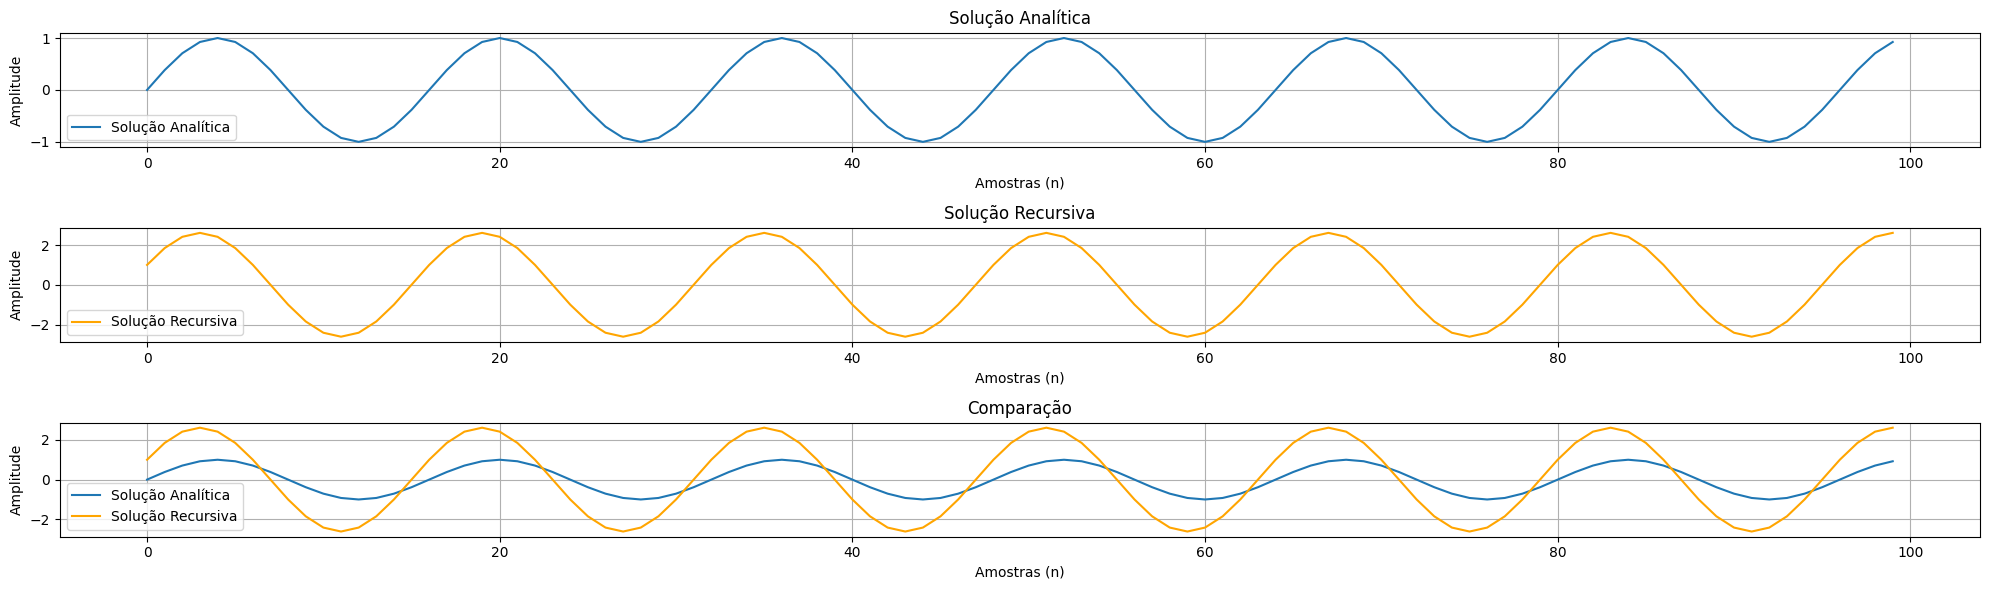

Erro Médio Quadrático (MSE): 1.5291421356237316


In [3]:
# Código da questão 3b.

# Definição dos coeficientes do sistema
a = [1, -2*np.cos(np.pi/8), 1]
N = 100  # Número de amostras

# Resposta ao impulso analítica
def h_analytical(n):
    return np.sin(np.pi/8 * n)

# Resposta ao impulso iterativa
def h_iterative(n):
    h = np.zeros(N)
    h[0] = 1
    h[1] = 2*np.cos(np.pi/8)
    for i in range(2, n):
        h[i] = 2*np.cos(np.pi/8)*h[i-1] - h[i-2]
    return h

# Calcular resposta ao impulso analítica
n_values = np.arange(N)
h_analytical_values = h_analytical(n_values)

# Calcular resposta ao impulso iterativa
h_iterative_values = h_iterative(N)

# Plotar os gráficos das duas respostas
plt.figure(figsize=(20, 6))

# Gráfico da solução analítica
plt.subplot(311)
plt.plot(n_values, h_analytical_values, label='Solução Analítica')
plt.title('Solução Analítica')
plt.xlabel('Amostras (n)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

# Gráfico da solução recursiva
plt.subplot(312)
plt.plot(n_values, h_iterative_values, label='Solução Recursiva', color='orange')
plt.title('Solução Recursiva')
plt.xlabel('Amostras (n)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

# Gráfico da comparação entre as soluções
plt.subplot(313)
plt.plot(n_values, h_analytical_values, label='Solução Analítica')
plt.plot(n_values, h_iterative_values, label='Solução Recursiva', color='orange')
plt.title('Comparação')
plt.xlabel('Amostras (n)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Calcular erro médio quadrático
mse = np.mean((h_analytical_values[:N] - h_iterative_values)**2)
print("Erro Médio Quadrático (MSE):", mse)


